In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

sys.path.insert(0, "../..")
from species_traits import Pecan

file_path = "Photosynthesis Stomatal Conductance Reduction and Dry Weight Data.xlsx"
df = pd.read_excel(file_path, sheet_name="Campos-Villareal Data", skiprows=9)
df = df.rename(columns={df.columns[0]: "salinity_dS_m", "Salinity(mMol) (Approximate)": "salinity_mMol"})

# Leaf Na+ (mg/kg DW) per cultivar, digitized from Campos-Villareal Fig. 1a, taken above each cultivar's
# control (0.08 dS/m, row 0) so controls sit at (0, 0), and converted to mM in leaf water
MW_NA = 22.99  # g/mol
ions = pd.read_excel(file_path, sheet_name="Campos-Villareal Ion Accum", skiprows=2)
leaf_na_abs = (ions.query("ion == 'Na+' and compartment == 'leaf'")
               .pivot(index="salinity_dS_m", columns="cultivar", values="value")
               .loc[df["salinity_dS_m"]].reset_index(drop=True))
leaf_na = leaf_na_abs - leaf_na_abs.iloc[0]
MGKG_TO_MM = (1 - Pecan.LWC) / Pecan.LWC / MW_NA
leaf_mM = leaf_na * MGKG_TO_MM

def leaf_na_axis(ax, mgkg_ticks=np.arange(0, 1001, 200), above_control=True):
    """Label a leaf-mM x-axis with mg/kg DW ticks and the matching mM in parentheses."""
    ax.set_xticks(mgkg_ticks * MGKG_TO_MM, [f"{v:.0f}\n[{v * MGKG_TO_MM:.1f}]" for v in mgkg_ticks])
    ax.set_xlim(0, mgkg_ticks[-1] * MGKG_TO_MM)
    for points in ax.collections:
        points.set_clip_on(False)  # keep control points at (0, 0) fully visible
    basis = " above control" if above_control else ""
    ax.set_xlabel(f"Leaf Na$^+$ Concentration{basis} (mg kg$^{{-1}}$ DW)\n[mM with LWC = {Pecan.LWC:.0%}]")

print(leaf_na.round(0).assign(salinity_dS_m=df["salinity_dS_m"]))
print(leaf_mM.round(1).assign(salinity_dS_m=df["salinity_dS_m"]))
df

cultivar  Apache  Riverside   SVA1   SVA2  salinity_dS_m
0            0.0        0.0    0.0    0.0           0.08
1          153.0      341.0  693.0  406.0           2.50
2          280.0      690.0  697.0  165.0           3.00
3          502.0      962.0  728.0  398.0           3.50
cultivar  Apache  Riverside  SVA1  SVA2  salinity_dS_m
0            0.0        0.0   0.0   0.0           0.08
1            4.3        9.5  19.3  11.3           2.50
2            7.8       19.2  19.4   4.6           3.00
3           14.0       26.7  20.2  11.1           3.50


,salinity_dS_m,salinity_mMol,Apache,Riverside,SVA1,SVA2,Percent_Baseline_Apache,Percent_Baseline_Riverside,Percent_Baseline_SVA1,Percent_Baseline_SVA2,Percent_Reduction_Percent_Baseline_Apache,Percent_Reduction_Percent_Baseline_Riverside,Percent_Reduction_Percent_Baseline_SVA1,Percent_Reduction_Percent_Baseline_SVA2,Unnamed: 14
0,0.08,0.8,5.2,5.3,5.2,4.3,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN
1,2.50,25.0,3.7,4.3,4.7,4.0,0.711538,0.811321,0.903846,0.930233,0.288462,0.188679,0.096154,0.069767,NaN
2,3.00,30.0,2.6,3.7,3.9,2.7,0.500000,0.698113,0.750000,0.627907,0.500000,0.301887,0.250000,0.372093,NaN
3,3.50,35.0,1.8,3.7,2.9,2.6,0.346154,0.698113,0.557692,0.604651,0.653846,0.301887,0.442308,0.395349,NaN


In [2]:
# ── Model functions (threshold always explicit) ───────────────────────────────
def piecewise_model(x, slope, threshold):
    return slope * np.maximum(0.0, x - threshold)

def piecewise_power_model(x, a, b, threshold):
    """b is constrained to (0, 1] during fitting."""
    return a * np.maximum(0.0, x - threshold) ** b

# ── Cultivar series ───────────────────────────────────────────────────────────
reduction_cols = [
    "Percent_Reduction_Percent_Baseline_Apache",
    "Percent_Reduction_Percent_Baseline_Riverside",
    "Percent_Reduction_Percent_Baseline_SVA1",
    "Percent_Reduction_Percent_Baseline_SVA2",
]
cultivar_names = ["Apache", "Riverside", "SVA1", "SVA2"]

# ── Helpers ───────────────────────────────────────────────────────────────────
def _r2(y, y_pred):
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - np.sum((y - y_pred) ** 2) / ss_tot if ss_tot > 0 else np.nan

def fit_piecewise(x, y, label, threshold=None):
    """Fit piecewise linear model.
    threshold : float  → fixed at that value
    threshold : None   → fitted as a free parameter
    """
    if threshold is not None:
        fn = lambda x, slope: piecewise_model(x, slope, threshold)
        (slope,), _ = curve_fit(fn, x, y, p0=[0.05], bounds=([0], [np.inf]))
        t = threshold
    else:
        (slope, t), _ = curve_fit(
            piecewise_model, x, y, p0=[0.05, x.min()],
            bounds=([0, 0], [np.inf, np.inf]),
        )
    return {"Cultivar": label, "Slope": slope, "Threshold": t,
            "R2": _r2(y, piecewise_model(x, slope, t))}

def fit_piecewise_power(x, y, label, threshold=None):
    """Fit piecewise power-law model (b ≤ 1).
    threshold : float  → fixed at that value
    threshold : None   → fitted as a free parameter
    """
    if threshold is not None:
        fn = lambda x, a, b: piecewise_power_model(x, a, b, threshold)
        (a, b), _ = curve_fit(
            fn, x, y, p0=[0.05, 0.8],
            bounds=([0, 0], [np.inf, 1.0]), maxfev=10000,
        )
        t = threshold
    else:
        (a, b, t), _ = curve_fit(
            piecewise_power_model, x, y, p0=[0.05, 0.8, x.min()],
            bounds=([0, 0, 0], [np.inf, 1.0, np.inf]), maxfev=10000,
        )
    return {"Cultivar": label, "a": a, "b": b, "Threshold": t,
            "R2": _r2(y, piecewise_power_model(x, a, b, t))}

# ── Run fits ──────────────────────────────────────────────────────────────────
FIXED_THRESHOLD = 0  # mM above control — set to None to fit threshold freely

results, power_results = [], []
for col, name in zip(reduction_cols, cultivar_names):
    results.append(fit_piecewise(leaf_mM[name].values, df[col].values, name, threshold=FIXED_THRESHOLD))
    power_results.append(fit_piecewise_power(leaf_mM[name].values, df[col].values, name, threshold=FIXED_THRESHOLD))

x_all = np.concatenate([leaf_mM[name].values for name in cultivar_names])
y_all = np.concatenate([df[col].values for col in reduction_cols])
results.append(fit_piecewise(x_all, y_all, "Combined", threshold=FIXED_THRESHOLD))
power_results.append(fit_piecewise_power(x_all, y_all, "Combined", threshold=FIXED_THRESHOLD))

results_df = pd.DataFrame(results).set_index("Cultivar")
power_results_df = pd.DataFrame(power_results).set_index("Cultivar")

print("=== Piecewise Linear ===")
display(results_df)
print("\n=== Piecewise Power Law ===")
display(power_results_df)

=== Piecewise Linear ===


,Slope,Threshold,R2
Cultivar,,,
Apache,0.052086,0,0.921992
Riverside,0.013344,0,0.852200
SVA1,0.013522,0,0.502837
SVA2,0.025332,0,-0.008898
Combined,0.018232,0,0.039747



=== Piecewise Power Law ===


,a,b,Threshold,R2
Cultivar,,,,
Apache,0.126809,6.299347e-01,0,0.989985
Riverside,0.073980,4.437453e-01,0,0.980919
SVA1,0.013522,1.000000e+00,0,0.502837
SVA2,0.279070,2.054396e-20,0,0.469565
Combined,0.321703,1.391108e-17,0,0.505527


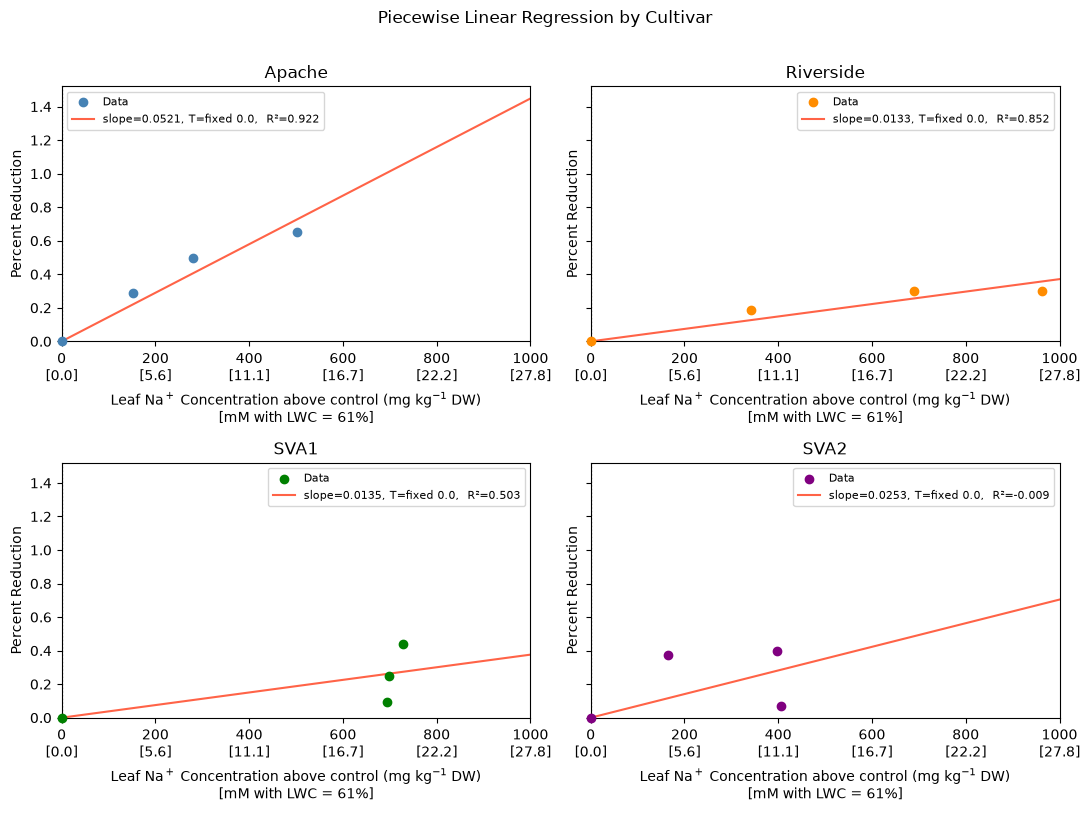

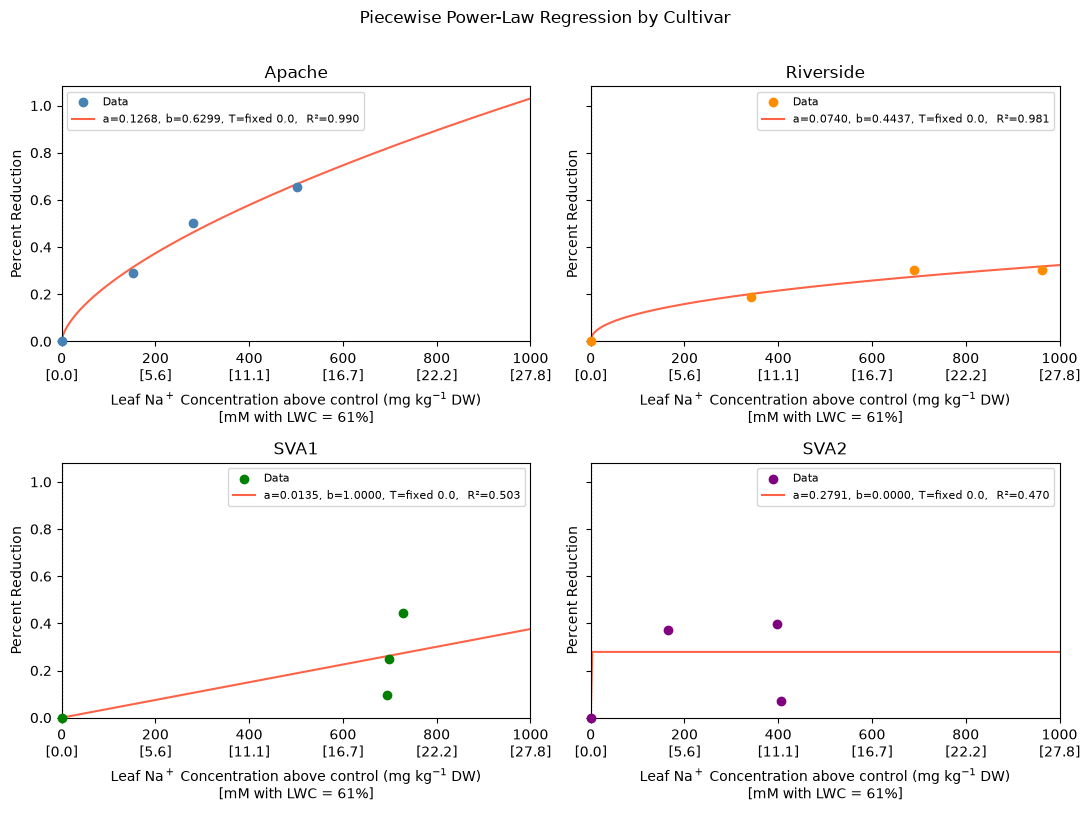

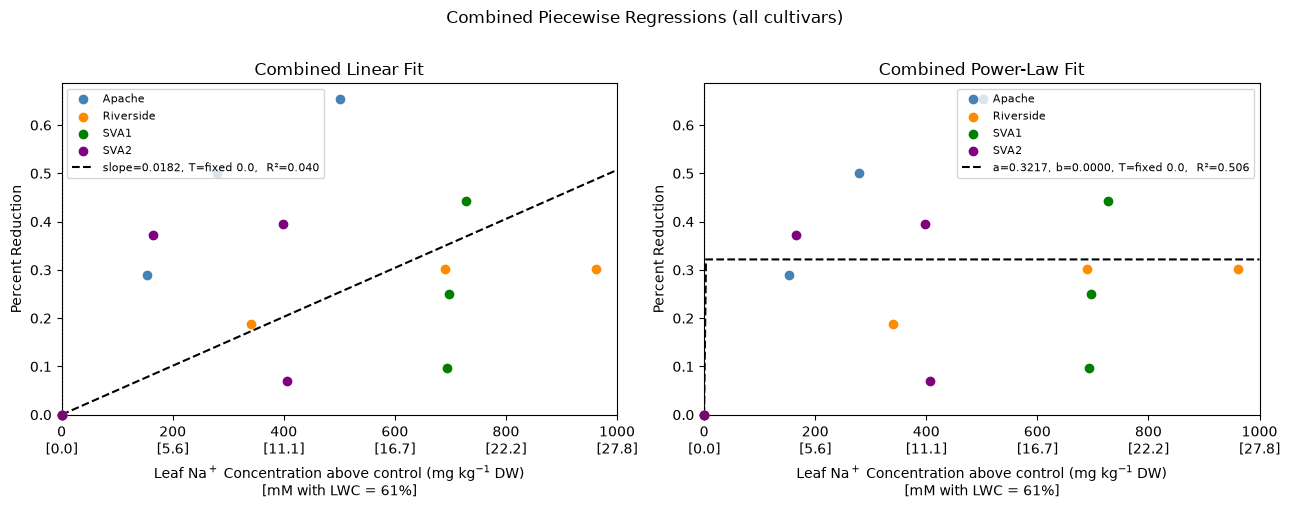

In [3]:

x_plot = np.linspace(0, 1000 * MGKG_TO_MM, 300)
colors = ["steelblue", "darkorange", "green", "purple"]
threshold_fixed = FIXED_THRESHOLD is not None

def _threshold_label(t):
    return f"T={'fixed ' if threshold_fixed else 'fit '}{t:.1f}"

# ── Per-cultivar subplots: Linear ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, col, name, color in zip(axes.flat, reduction_cols, cultivar_names, colors):
    row = results_df.loc[name]
    ax.scatter(leaf_mM[name], df[col].values, color=color, zorder=5, label="Data")
    ax.plot(x_plot, piecewise_model(x_plot, row["Slope"], row["Threshold"]), color="tomato",
            label=f"slope={row['Slope']:.4f}, {_threshold_label(row['Threshold'])},  R²={row['R2']:.3f}")
    ax.axvline(row["Threshold"], color="gray", linestyle=":", linewidth=1)
    ax.set_title(name)
    leaf_na_axis(ax)
    ax.set_ylabel("Percent Reduction")
    ax.legend(fontsize=8)
    ax.set_ylim(0, None)
fig.suptitle("Piecewise Linear Regression by Cultivar", y=1.01)
plt.tight_layout()
plt.show()

# ── Per-cultivar subplots: Power Law ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, col, name, color in zip(axes.flat, reduction_cols, cultivar_names, colors):
    row = power_results_df.loc[name]
    ax.scatter(leaf_mM[name], df[col].values, color=color, zorder=5, label="Data")
    ax.plot(x_plot, piecewise_power_model(x_plot, row["a"], row["b"], row["Threshold"]), color="tomato",
            label=f"a={row['a']:.4f}, b={row['b']:.4f}, {_threshold_label(row['Threshold'])},  R²={row['R2']:.3f}")
    ax.axvline(row["Threshold"], color="gray", linestyle=":", linewidth=1)
    ax.set_title(name)
    leaf_na_axis(ax)
    ax.set_ylabel("Percent Reduction")
    ax.legend(fontsize=8)
    ax.set_ylim(0, None)
fig.suptitle("Piecewise Power-Law Regression by Cultivar", y=1.01)
plt.tight_layout()
plt.show()

# ── Combined plots: Linear & Power Law side by side ───────────────────────────
fig2, (ax_lin, ax_pow) = plt.subplots(1, 2, figsize=(13, 5))
combined_lin = results_df.loc["Combined"]
combined_pow = power_results_df.loc["Combined"]

for col, name, color in zip(reduction_cols, cultivar_names, colors):
    ax_lin.scatter(leaf_mM[name], df[col].values, color=color, label=name, zorder=5)
    ax_pow.scatter(leaf_mM[name], df[col].values, color=color, label=name, zorder=5)

ax_lin.plot(x_plot, piecewise_model(x_plot, combined_lin["Slope"], combined_lin["Threshold"]), "k--",
            label=f"slope={combined_lin['Slope']:.4f}, {_threshold_label(combined_lin['Threshold'])},  R²={combined_lin['R2']:.3f}")
ax_lin.axvline(combined_lin["Threshold"], color="gray", linestyle=":", linewidth=1)

ax_pow.plot(x_plot, piecewise_power_model(x_plot, combined_pow["a"], combined_pow["b"], combined_pow["Threshold"]), "k--",
            label=f"a={combined_pow['a']:.4f}, b={combined_pow['b']:.4f}, {_threshold_label(combined_pow['Threshold'])},  R²={combined_pow['R2']:.3f}")
ax_pow.axvline(combined_pow["Threshold"], color="gray", linestyle=":", linewidth=1)

for ax, title in [(ax_lin, "Combined Linear Fit"), (ax_pow, "Combined Power-Law Fit")]:
    leaf_na_axis(ax)
    ax.set_ylabel("Percent Reduction")
    ax.set_title(title)
    ax.set_ylim(0, None)
    ax.legend(fontsize=8)

fig2.suptitle("Combined Piecewise Regressions (all cultivars)", y=1.01)
plt.tight_layout()
plt.show()

=== Piecewise Linear (threshold fitted) ===


,Slope,Threshold,R2
Cultivar,,,
Apache,0.052086,3.807793e-11,0.921992
Riverside,0.013344,5.921238e-21,0.852200
SVA1,0.309067,1.879049e+01,0.934018
SVA2,0.025332,7.149918e-17,-0.008898
Combined,0.018232,7.230574e-15,0.039747



=== Piecewise Power Law (threshold fitted) ===


,a,b,Threshold,R2
Cultivar,,,,
Apache,0.328560,2.945954e-01,3.618967e+00,1.000000
Riverside,0.283592,2.421819e-02,9.482819e+00,0.999853
SVA1,0.446859,2.624499e-01,1.928286e+01,1.000000
SVA2,0.279070,5.185719e-16,6.064024e-15,0.469565
Combined,0.321702,1.084049e-12,1.546665e-05,0.505527


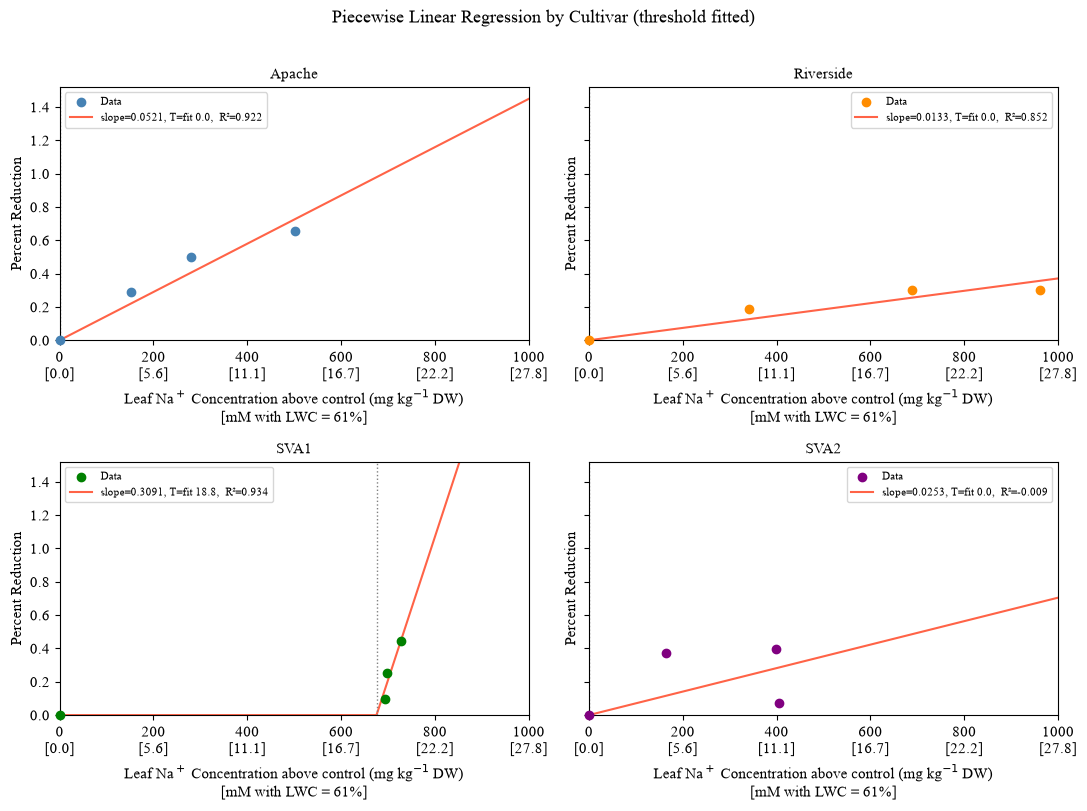

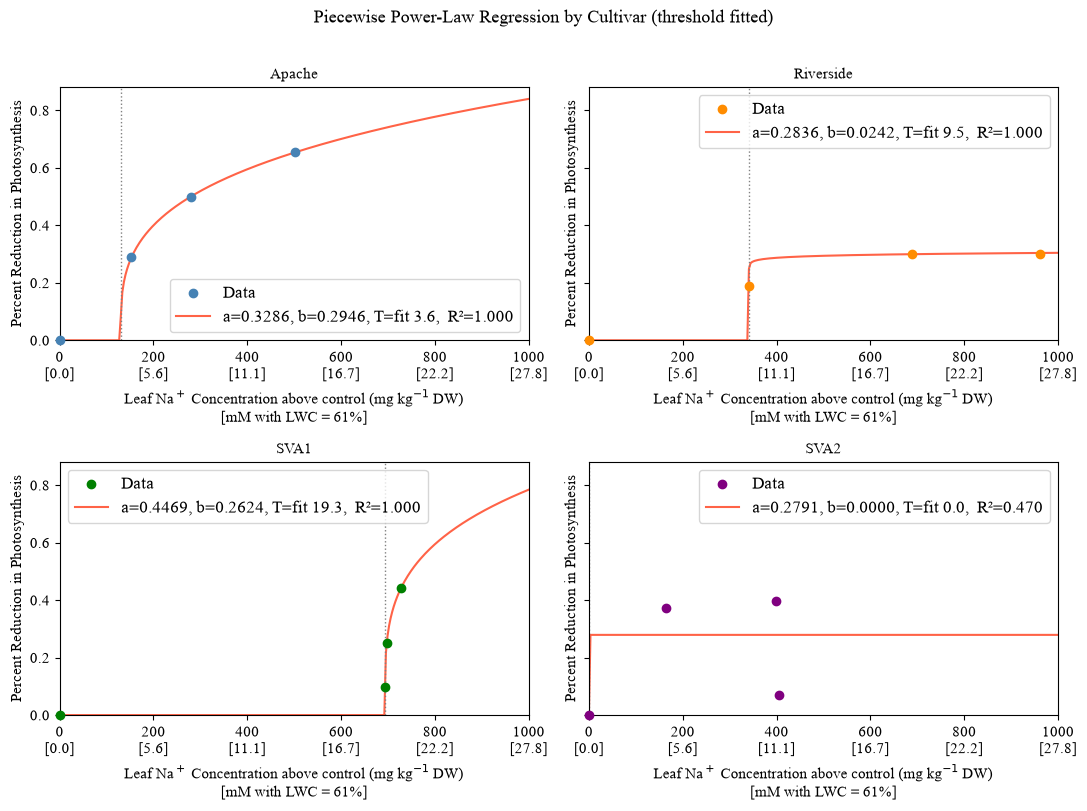

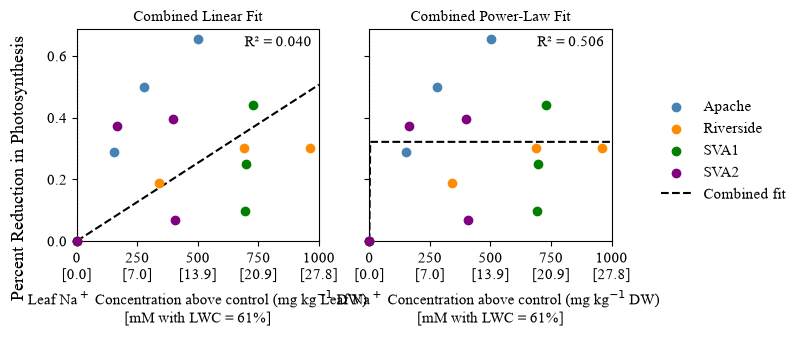

In [4]:
from pathlib import Path

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})
save_dir = Path("Figures")
save_dir.mkdir(exist_ok=True)
#    ── Fits with threshold as a free parameter ───────────────────────────────────
free_results, free_power_results = [], []
for col, name in zip(reduction_cols, cultivar_names):
    free_results.append(fit_piecewise(leaf_mM[name].values, df[col].values, name, threshold=None))
    free_power_results.append(fit_piecewise_power(leaf_mM[name].values, df[col].values, name, threshold=None))

free_results.append(fit_piecewise(x_all, y_all, "Combined", threshold=None))
free_power_results.append(fit_piecewise_power(x_all, y_all, "Combined", threshold=None))

free_results_df = pd.DataFrame(free_results).set_index("Cultivar")
free_power_results_df = pd.DataFrame(free_power_results).set_index("Cultivar")

print("=== Piecewise Linear (threshold fitted) ===")
display(free_results_df)
print("\n=== Piecewise Power Law (threshold fitted) ===")
display(free_power_results_df)

# ── Plots ─────────────────────────────────────────────────────────────────────
x_plot = np.linspace(0, 1000 * MGKG_TO_MM, 300)
colors = ["steelblue", "darkorange", "green", "purple"]

def _free_threshold_label(t):
    return f"T=fit {t:.1f}"

# Per-cultivar: Linear
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, col, name, color in zip(axes.flat, reduction_cols, cultivar_names, colors):
    row = free_results_df.loc[name]
    ax.scatter(leaf_mM[name], df[col].values, color=color, zorder=5, label="Data")
    ax.plot(x_plot, piecewise_model(x_plot, row["Slope"], row["Threshold"]), color="tomato",
            label=f"slope={row['Slope']:.4f}, {_free_threshold_label(row['Threshold'])},  R²={row['R2']:.3f}")
    ax.axvline(row["Threshold"], color="gray", linestyle=":", linewidth=1)
    ax.set_title(name)
    leaf_na_axis(ax)
    ax.set_ylabel("Percent Reduction")
    ax.legend(fontsize=8)
    ax.set_ylim(0, None)
fig.suptitle("Piecewise Linear Regression by Cultivar (threshold fitted)", y=1.01)
plt.tight_layout()
plt.show()

# Per-cultivar: Power Law
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for ax, col, name, color in zip(axes.flat, reduction_cols, cultivar_names, colors):
    row = free_power_results_df.loc[name]
    ax.scatter(leaf_mM[name], df[col].values, color=color, zorder=5, label="Data")
    ax.plot(x_plot, piecewise_power_model(x_plot, row["a"], row["b"], row["Threshold"]), color="tomato",
            label=f"a={row['a']:.4f}, b={row['b']:.4f}, {_free_threshold_label(row['Threshold'])},  R²={row['R2']:.3f}")
    ax.axvline(row["Threshold"], color="gray", linestyle=":", linewidth=1)
    ax.set_title(name)
    leaf_na_axis(ax)
    ax.set_ylabel("Percent Reduction in Photosynthesis")
    ax.legend(fontsize=12)
    ax.set_ylim(0, None)
fig.suptitle("Piecewise Power-Law Regression by Cultivar (threshold fitted)", y=1.01)
plt.tight_layout()
plt.show()

# Combined: Linear & Power Law side by side
fig2, (ax_lin, ax_pow) = plt.subplots(1, 2, figsize=(6.5, 3.5), sharey=True)
combined_lin = free_results_df.loc["Combined"]
combined_pow = free_power_results_df.loc["Combined"]

for col, name, color in zip(reduction_cols, cultivar_names, colors):
    ax_lin.scatter(leaf_mM[name], df[col].values, color=color, label=name, zorder=5)
    ax_pow.scatter(leaf_mM[name], df[col].values, color=color, label=name, zorder=5)

ax_lin.plot(x_plot, piecewise_model(x_plot, combined_lin["Slope"], combined_lin["Threshold"]), "k--",
            label="Combined fit")
ax_lin.axvline(combined_lin["Threshold"], color="gray", linestyle=":", linewidth=1)

ax_pow.plot(x_plot, piecewise_power_model(x_plot, combined_pow["a"], combined_pow["b"], combined_pow["Threshold"]), "k--",
            label="Combined fit")
ax_pow.axvline(combined_pow["Threshold"], color="gray", linestyle=":", linewidth=1)

for ax, title, fit in [(ax_lin, "Combined Linear Fit", combined_lin), (ax_pow, "Combined Power-Law Fit", combined_pow)]:
    leaf_na_axis(ax, np.arange(0, 1001, 250))
    ax.set_ylabel("")
    ax.set_title(title)
    ax.set_ylim(0, None)
    ax.text(0.97, 0.97, f"R² = {fit['R2']:.3f}", transform=ax.transAxes, ha="right", va="top")

fig2.legend(*ax_lin.get_legend_handles_labels(), loc="center left", bbox_to_anchor=(1.0, 0.55), frameon=False)

fig2.supylabel("Percent Reduction in Photosynthesis", x=0.02)
#fig2.suptitle("Combined Piecewise Regressions — threshold fitted (all cultivars)", y=1.01)
plt.tight_layout()
fig2.savefig(save_dir / "combined_piecewise_regressions.png", dpi=300, bbox_inches="tight")
fig2.savefig(save_dir / "combined_piecewise_regressions.pdf", bbox_inches="tight")
plt.show()

=== Processed data (per cultivar) ===


,salinity_dS_m,cultivar,leaf_Na_mgkg_DW,leaf_Na_mgkg_DW_above_control,leaf_Na_mM,leaf_Na_mM_above_control,A,reduction
0,0.08,Apache,163.99,0.00,4.561,0.000,5.2,0.000
1,0.08,Riverside,298.09,0.00,8.290,0.000,5.3,0.000
2,0.08,SVA1,254.02,0.00,7.064,0.000,5.2,0.000
3,0.08,SVA2,319.16,0.00,8.876,0.000,4.3,0.000
4,2.50,Apache,317.24,153.25,8.822,4.262,3.7,0.288
5,2.50,Riverside,639.08,340.99,17.773,9.483,4.3,0.189
6,2.50,SVA1,947.51,693.49,26.350,19.286,4.7,0.096
7,2.50,SVA2,725.29,406.13,20.170,11.294,4.0,0.070
8,3.00,Apache,443.68,279.69,12.339,7.778,2.6,0.500
9,3.00,Riverside,987.74,689.65,27.469,19.179,3.7,0.302



=== Treatment means across cultivars ===


,leaf_Na_mgkg_DW,leaf_Na_mgkg_DW_above_control,leaf_Na_mM,leaf_Na_mM_above_control,A,reduction
salinity_dS_m,,,,,,
0.08,258.815,0.000,7.198,0.000,5.000,0.000
2.50,657.280,398.465,18.279,11.081,4.175,0.165
3.00,716.668,457.853,19.930,12.733,3.225,0.355
3.50,906.320,647.505,25.204,18.007,2.750,0.450



=== Fits to treatment means ===


,Model,Threshold mode,Slope,Threshold,R2,a,b
0,Linear,T=0,0.023724,0.000000,0.892936,NaN,NaN
1,Linear,T fitted,0.035520,4.837388,0.924506,NaN,NaN
2,Power,T=0,NaN,0.000000,0.892936,0.023724,1.000000
3,Power,T fitted,NaN,11.064530,1.000000,0.326038,0.166302


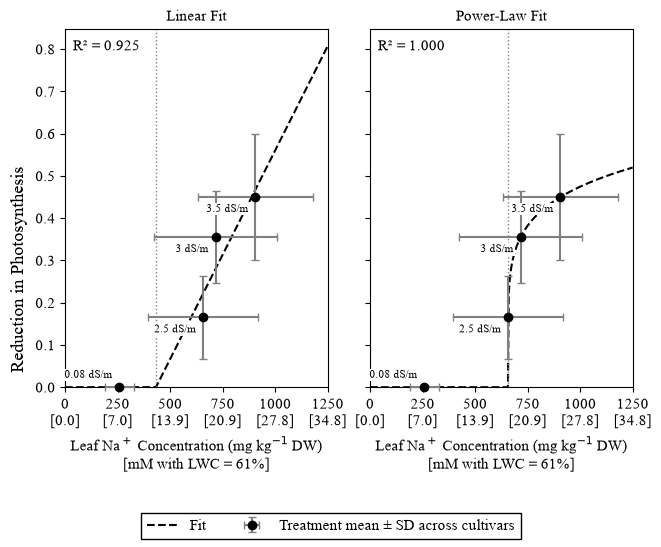

In [5]:
# ── Processed leaf Na+ table and treatment-mean fits ──────────────────────────────────────────────
# Rows: treatment level x cultivar. A is the photosynthetic rate (umol m-2 s-1).
processed = pd.DataFrame({
    "salinity_dS_m": np.repeat(df["salinity_dS_m"].values, len(cultivar_names)),
    "cultivar": np.tile(cultivar_names, len(df)),
    "leaf_Na_mgkg_DW": leaf_na_abs[cultivar_names].values.ravel(),
    "leaf_Na_mgkg_DW_above_control": leaf_na[cultivar_names].values.ravel(),
    "leaf_Na_mM": (leaf_na_abs[cultivar_names] * MGKG_TO_MM).values.ravel(),
    "leaf_Na_mM_above_control": leaf_mM[cultivar_names].values.ravel(),
    "A": df[cultivar_names].values.ravel(),
    "reduction": df[reduction_cols].values.ravel(),
})

# Treatment means across cultivars; reduction is taken from the mean A, not the mean of the reductions
by_level = processed.groupby("salinity_dS_m", sort=False)
means = by_level.mean(numeric_only=True)
means["reduction"] = 1 - means["A"] / means["A"].iloc[0]
sds = by_level.std(numeric_only=True)

out_dir = Path("../../output/photo_reduction")
out_dir.mkdir(parents=True, exist_ok=True)
processed.to_csv(out_dir / "campos_villareal_leaf_na_processed.csv", index=False)
means.to_csv(out_dir / "campos_villareal_leaf_na_treatment_means.csv")
print("=== Processed data (per cultivar) ===")
display(processed.round(3))
print("\n=== Treatment means across cultivars ===")
display(means.round(3))

x_mean = means["leaf_Na_mM_above_control"].values
y_mean = means["reduction"].values
mean_fits = pd.DataFrame([
    {"Model": "Linear", **fit_piecewise(x_mean, y_mean, "T=0", threshold=0)},
    {"Model": "Linear", **fit_piecewise(x_mean, y_mean, "T fitted", threshold=None)},
    {"Model": "Power", **fit_piecewise_power(x_mean, y_mean, "T=0", threshold=0)},
    {"Model": "Power", **fit_piecewise_power(x_mean, y_mean, "T fitted", threshold=None)},
]).rename(columns={"Cultivar": "Threshold mode"})
print("\n=== Fits to treatment means ===")
display(mean_fits)
mean_lin = mean_fits.iloc[1]
mean_pow = mean_fits.iloc[3]

# Plot: treatment means +/- SD across cultivars at actual leaf Na+; curves fitted above control are
# shifted right by the mean control leaf Na+ (c0)
c0 = means["leaf_Na_mM"].iloc[0]
x_abs = means["leaf_Na_mM"].values
x_plot_abs = np.linspace(0, 1250 * MGKG_TO_MM, 300)
fig3, (ax_lin, ax_pow) = plt.subplots(1, 2, figsize=(6.5, 5.5), sharey=True, layout="constrained")
for ax in (ax_lin, ax_pow):
    ax.errorbar(x_abs, y_mean, xerr=sds["leaf_Na_mM"], yerr=sds["reduction"],
                fmt="o", color="k", ecolor="gray", capsize=3, zorder=5, clip_on=False,
                label="Treatment mean ± SD across cultivars")
    for s, xi, yi in zip(means.index, x_abs, y_mean):
        ax.annotate(f"{s:g} dS/m", (xi, yi), textcoords="offset points", ha="right",
                    va="bottom" if yi == 0 else "top", xytext=(-5, 5) if yi == 0 else (-5, -5), fontsize=8,
                    bbox=dict(boxstyle="square,pad=0.1", fc="white", ec="none"), zorder=6)
ax_lin.plot(x_plot_abs, piecewise_model(x_plot_abs - c0, mean_lin["Slope"], mean_lin["Threshold"]), "k--", label="Fit")
ax_pow.plot(x_plot_abs, piecewise_power_model(x_plot_abs - c0, mean_pow["a"], mean_pow["b"], mean_pow["Threshold"]), "k--", label="Fit")
for ax, title, fit in [(ax_lin, "Linear Fit", mean_lin), (ax_pow, "Power-Law Fit", mean_pow)]:
    ax.axvline(fit["Threshold"] + c0, color="gray", linestyle=":", linewidth=1)
    leaf_na_axis(ax, np.arange(0, 1251, 250), above_control=False)
    ax.set_title(title)
    ax.set_ylim(0, None)
    ax.text(0.03, 0.97, f"R² = {fit['R2']:.3f}", transform=ax.transAxes, ha="left", va="top")

fig3.legend(*ax_lin.get_legend_handles_labels(), loc="outside lower center", ncol=2,
            fancybox=False, edgecolor="k", framealpha=1)
fig3.get_layout_engine().set(h_pad=0.15)  # inches; widens the gap between the x-axis labels and the legend
fig3.supylabel("Reduction in Photosynthesis")
fig3.savefig(save_dir / "treatment_mean_piecewise_regressions.png", dpi=300)
fig3.savefig(save_dir / "treatment_mean_piecewise_regressions.pdf")
plt.show()